In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ضبط تنسيق الرسومات
sns.set_theme(style= "whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# جلب البيانات التاريخية
url ="https://raw.githubusercontent.com/selva86/datasets/master/MarketSales.csv"
try:
  df = pd.read_csv(url)
  print("تم تحميل البيانات بنجاح!")
  print(f" ابعاد البيانات: {df.shape[0]} صف و {df.shape[1]} اعمدة\n")

except Exception as e:
  url_alt = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
  df = pd.read_csv(url_alt)
  print("تم تحميل البيانات بنجاح")
df.head()



تم تحميل البيانات بنجاح


,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


In [7]:
# 1. التحقق من معلومات البيانات وانواع الاعمدة
print("--- معلومات الاعمدة وانواع البيانات ---")
print(df.info)

#  2. تحويل عمود ds الى صيغة Datetime
df['ds'] = pd.to_datetime(df['ds'])

# 3. التحقق من القيم المفقودة
print("\n--- عدد القيم المفقودة في كل عمود ---")
print(df.isnull().sum())


# 4. ملخص احصائي سريع للطلب (y)
print("\n--- الملخص الاحصائي ---")
print(df.describe())

--- معلومات الاعمدة وانواع البيانات ---
<bound method DataFrame.info of               ds          y
0     2007-12-10   9.590761
1     2007-12-11   8.519590
2     2007-12-12   8.183677
3     2007-12-13   8.072467
4     2007-12-14   7.893572
...          ...        ...
2900  2016-01-16   7.817223
2901  2016-01-17   9.273878
2902  2016-01-18  10.333775
2903  2016-01-19   9.125871
2904  2016-01-20   8.891374

[2905 rows x 2 columns]>

--- عدد القيم المفقودة في كل عمود ---
ds    0
y     0
dtype: int64

--- الملخص الاحصائي ---
                                  ds            y
count                           2905  2905.000000
mean   2012-01-15 10:11:11.669535232     8.138958
min              2007-12-10 00:00:00     5.262690
25%              2010-01-12 00:00:00     7.514800
50%              2012-01-23 00:00:00     7.997999
75%              2014-01-21 00:00:00     8.580168
max              2016-01-20 00:00:00    12.846747
std                              NaN     0.845957


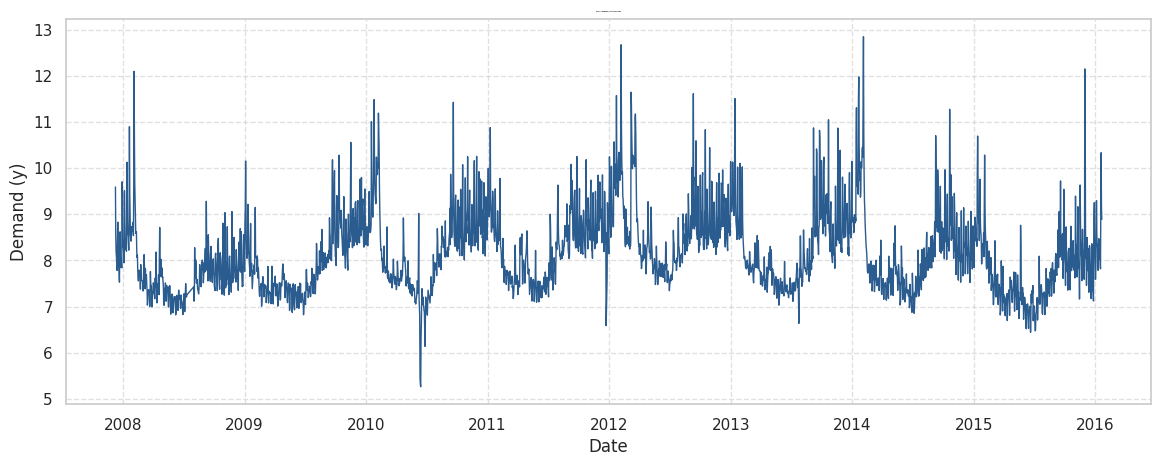

/tmp/ipykernel_4342/566445125.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='dayofweek', y='y', order=days_order, palette='Blues_d')


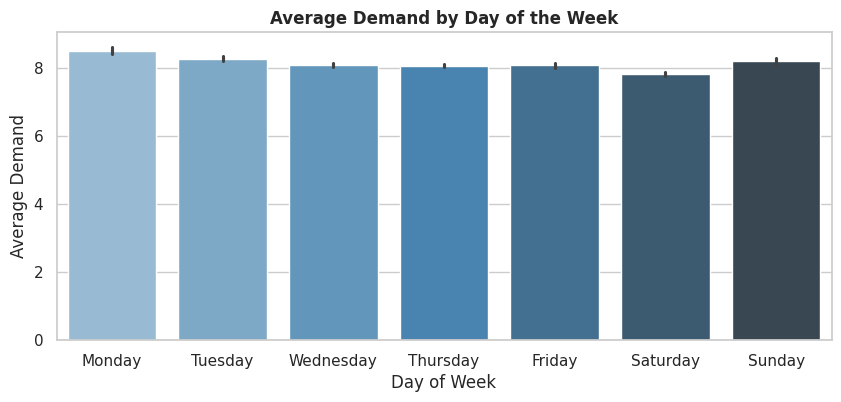

In [8]:
# 1. استخراج الخصائص الزمنية من عمود التاريخ
df['year'] = df['ds'].dt.year
df['month'] = df['ds'].dt.month
df['day'] = df['ds'].dt.day
df['dayofweek'] = df['ds'].dt.day_name()

# 2. رسم السلسلة الزمنية الكلية لملاحظة الاتجاه العام (Trend)
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['y'], color= '#2b5c8f', linewidth=1)
plt.title('Overall Demand/Sales Over Time', fontsize=1, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand (y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. رسم متوسط الطلب حسب ايام الاسبوع لرؤية الموسمية الاسبوعية
plt.figure(figsize=(10,4))
days_order = ['Monday', 'Tuesday', 'Wednesday' , 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='dayofweek', y='y', order=days_order, palette='Blues_d')
plt.title('Average Demand by Day of the Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand')
plt.show()

In [9]:
# 1. استدعاء مكتبة Prophet
from prophet import Prophet

# 2. تقسيم البيانات الى تدريب واختبار
# سنترك اخر سنة 2016-2015 لاختبار دقة التنبؤ
train_df = df[df['ds'] < '2015-01-01'][['ds','y']]
test_df = df[df['ds'] >= '2015-01-01'][['ds', 'y']]

print(f" عدد ايام التدريب : {len(train_df)}")
print(f" عدد ايام الاختبار : {len(test_df)}")

# 3. انشاء النموذج وتدريبه
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(train_df)

print("\n تم تدريب نموذج Prophet بنجاح!")

 عدد ايام التدريب : 2522
 عدد ايام الاختبار : 383


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



 تم تدريب نموذج Prophet بنجاح!


📊 متوسط الخطأ المطلق (MAE): 0.4332
📊 جذر متوسط مربع الخطأ (RMSE): 0.5508


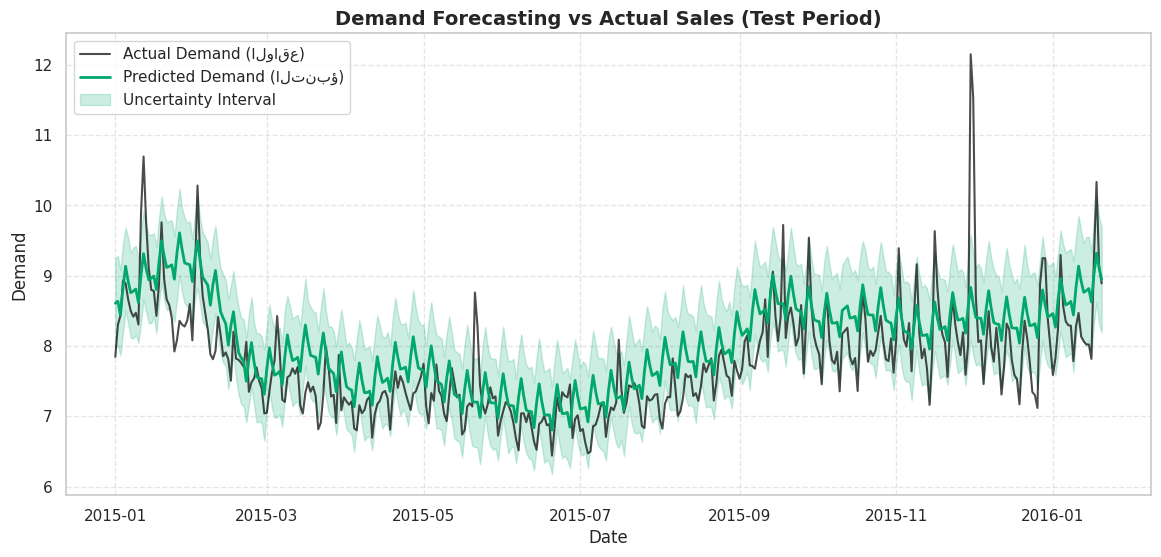

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. إنشاء جدول التواريخ المستقبلية لفترة الاختبار
future = test_df[['ds']].copy()

# 2. التنبؤ باستخدام النموذج
forecast = model.predict(future)

# 3. دمج التنبؤات مع البيانات الحقيقية لمقارنتها
results = test_df.merge(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

# 4. حساب معايير الدقة والخطأ
mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))

print(f"📊 متوسط الخطأ المطلق (MAE): {mae:.4f}")
print(f"📊 جذر متوسط مربع الخطأ (RMSE): {rmse:.4f}")

# 5. رسم المقارنة بين الطلب الحقيقي والتنبؤ
plt.figure(figsize=(14, 6))
plt.plot(results['ds'], results['y'], label='Actual Demand (الواقع)', color='black', alpha=0.7)
plt.plot(results['ds'], results['yhat'], label='Predicted Demand (التنبؤ)', color='#00a86b', linewidth=2)
plt.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'], color='#00a86b', alpha=0.2, label='Uncertainty Interval')
plt.title('Demand Forecasting vs Actual Sales (Test Period)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


✅ تم التنبؤ بـ 90 يوماً مستقبلياً وحفظ ملفات النموذج بنجاح!


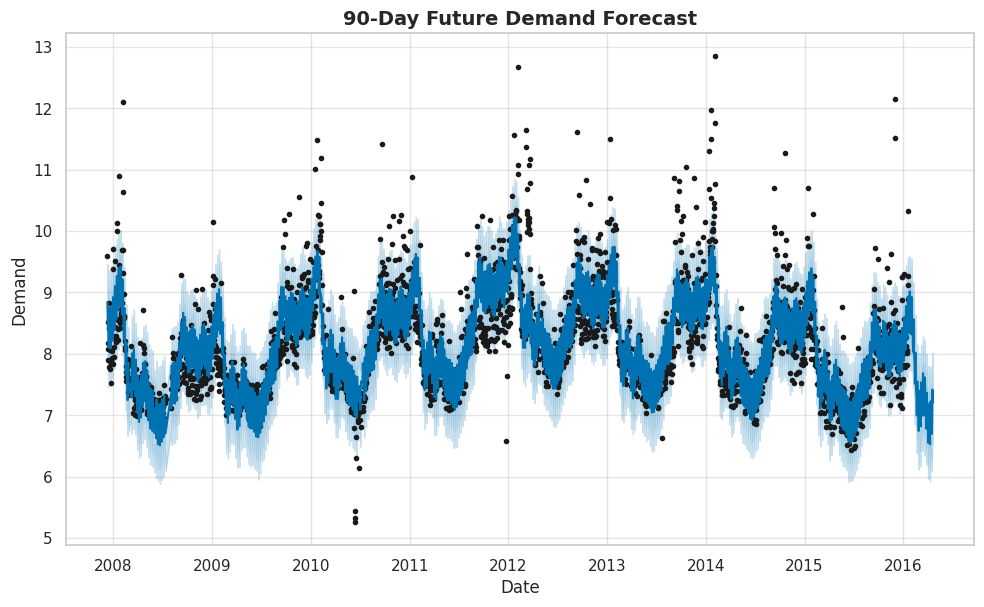

In [11]:
import joblib

# 1. إعادة تدريب النموذج على كامل البيانات المتاحة لزيادة الدقة
final_model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
final_model.fit(df[['ds', 'y']])

# 2. إنشاء تواريخ مستقبلية لـ 90 يوماً قادمة
future_dates = final_model.make_future_dataframe(periods=90)
forecast_future = final_model.predict(future_dates)

# 3. حفظ نتائج التنبؤ والنموذج
forecast_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('demand_forecast_results.csv', index=False)
joblib.dump(final_model, 'demand_forecasting_model.pkl')

print("✅ تم التنبؤ بـ 90 يوماً مستقبلياً وحفظ ملفات النموذج بنجاح!")

# 4. رسم التنبؤ المستقبلي الشامل
fig = final_model.plot(forecast_future)
plt.title('90-Day Future Demand Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

In [13]:
from google.colab import files

# تنزيل ملف النتائج والنموذج والمفكرة
files.download('demand_forecast_results.csv')
files.download('demand_forecasting_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>